In [2]:
!pip install datasets torchvision torch --quiet


In [4]:
from datasets import load_dataset

# This will download ~10–11 GB the first time
ds = load_dataset("wltjr1007/Camelyon17-WILDS")

print(ds)                    # shows train / validation / test
print(ds["train"].column_names)


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'center', 'image_id', 'patient', 'node', 'x_coord', 'y_coord', 'slide'],
        num_rows: 302436
    })
    validation: Dataset({
        features: ['image', 'label', 'center', 'image_id', 'patient', 'node', 'x_coord', 'y_coord', 'slide'],
        num_rows: 68464
    })
    test: Dataset({
        features: ['image', 'label', 'center', 'image_id', 'patient', 'node', 'x_coord', 'y_coord', 'slide'],
        num_rows: 85054
    })
})
['image', 'label', 'center', 'image_id', 'patient', 'node', 'x_coord', 'y_coord', 'slide']


In [6]:
#Transform + custom Dataset

In [8]:
from torch.utils.data import Dataset
from torchvision import transforms

# Transform: force RGB (3 channels) → resize → tensor → normalize
img_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),  # important fix
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

class CamelyonHFDataset(Dataset):
    def __init__(self, hf_split, transform=None):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        ex = self.hf_split[idx]
        image = ex["image"]          # PIL image
        label = ex["label"]          # 0/1
        center = ex["center"]        # hospital/domain ID

        if self.transform is not None:
            image = self.transform(image)

        return image, label, center


In [10]:
#Wrap splits + DataLoaders

In [12]:
from torch.utils.data import DataLoader

# Wrap HF splits with our PyTorch Dataset
train_ds = CamelyonHFDataset(ds["train"],       transform=img_transform)
val_ds   = CamelyonHFDataset(ds["validation"],  transform=img_transform)
test_ds  = CamelyonHFDataset(ds["test"],        transform=img_transform)

print("Sizes:", len(train_ds), len(val_ds), len(test_ds))

BATCH_SIZE = 32
NUM_WORKERS = 0   # keep 0 on Mac/Jupyter

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

# Sanity-check one batch
images, labels, centers = next(iter(train_loader))
print("Images shape :", images.shape)   # expect [B, 3, 224, 224]
print("Labels shape :", labels.shape)   # [B]
print("Centers shape:", centers.shape)  # [B]
print("Unique centers in batch:", centers.unique())


Sizes: 302436 68464 85054
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Centers shape: torch.Size([32])
Unique centers in batch: tensor([0, 3, 4])


In [14]:
#Simple ResNet forward

In [16]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)   # 2 classes (tumor / normal)
resnet = resnet.to(device)

images = images.to(device)

with torch.no_grad():
    logits = resnet(images)

print("Logits shape:", logits.shape)   # expect [B, 2]


Using device: cpu
Logits shape: torch.Size([32, 2])


In [19]:
# train on ~2000 examples to get the pipeline working, Use a much smaller subset

In [21]:
import numpy as np
from torch.utils.data import DataLoader

subset_size = 2000   # instead of 10_000

all_idx = np.random.permutation(len(ds["train"]))[:subset_size]
train_small_hf = ds["train"].select(all_idx.tolist())

print("Original train size:", len(ds["train"]))
print("Subsampled size    :", len(train_small_hf))

train_small_ds = CamelyonHFDataset(train_small_hf, transform=img_transform)

BATCH_SIZE = 32

train_small_loader = DataLoader(
    train_small_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)


Original train size: 302436
Subsampled size    : 2000


In [23]:
# batches processed per epoch

In [25]:
import torch.nn.functional as F
import torch.optim as optim

optimizer = optim.Adam(resnet.parameters(), lr=1e-4)

def train_one_epoch(model, loader, max_batches=50):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for batch_idx, (images, labels, centers) in enumerate(loader):
        if batch_idx >= max_batches:   # <-- stop after max_batches
            break

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_n += labels.size(0)

    avg_loss = total_loss / total_n
    acc = total_correct / total_n
    return avg_loss, acc


def evaluate(model, loader, max_batches=50):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0

    with torch.no_grad():
        for batch_idx, (images, labels, centers) in enumerate(loader):
            if batch_idx >= max_batches:   # <-- stop early
                break

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = F.cross_entropy(logits, labels)

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_n += labels.size(0)

    avg_loss = total_loss / total_n
    acc = total_correct / total_n
    return avg_loss, acc


In [27]:
# training loop

In [29]:
EPOCHS = 1 

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(resnet, train_small_loader, max_batches=50)
    val_loss, val_acc = evaluate(resnet, val_loader, max_batches=50)

    print(f"Epoch {epoch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")


Epoch 1: train_loss=0.2094, train_acc=0.915, val_loss=0.0901, val_acc=0.959


In [32]:
# Get probabilities, labels, and centers from a loader

In [34]:
import numpy as np
import torch.nn.functional as F

def get_probs_labels_centers(model, loader, max_batches=None):
    model.eval()
    all_probs = []
    all_labels = []
    all_centers = []

    with torch.no_grad():
        for b, (images, labels, centers) in enumerate(loader):
            if max_batches is not None and b >= max_batches:
                break

            images = images.to(device)
            logits = model(images)
            probs = F.softmax(logits, dim=1)  # [B, 2]

            all_probs.append(probs.cpu())
            all_labels.append(labels)
            all_centers.append(centers)

    all_probs   = torch.cat(all_probs)          # [N, 2]
    all_labels  = torch.cat(all_labels)         # [N]
    all_centers = torch.cat(all_centers)        # [N]

    return all_probs.numpy(), all_labels.numpy(), all_centers.numpy()


In [36]:
# use some batch limits so it stays fast on CPU
val_probs,  val_labels,  val_centers  = get_probs_labels_centers(resnet, val_loader,  max_batches=200)
test_probs, test_labels, test_centers = get_probs_labels_centers(resnet, test_loader, max_batches=200)

print("val_probs:",  val_probs.shape)
print("test_probs:", test_probs.shape)
print("unique val centers:",  np.unique(val_centers))
print("unique test centers:", np.unique(test_centers))


val_probs: (6400, 2)
test_probs: (6400, 2)
unique val centers: [0 3 4]
unique test centers: [2]


In [38]:
# Baseline split conformal prediction (global)

In [40]:
def split_conformal_calibration(probs, labels, alpha=0.1):
    """
    probs: [N, K] softmax probabilities
    labels: [N] true labels
    """
    # probability assigned to the true label
    p_true = probs[np.arange(len(labels)), labels]
    scores = 1.0 - p_true              # nonconformity

    # empirical (1 - alpha) quantile
    q_hat = np.quantile(scores, 1 - alpha)
    return q_hat, scores


In [42]:
alpha = 0.1  # target miscoverage (90% coverage)

q_hat, val_scores = split_conformal_calibration(val_probs, val_labels, alpha)
print("Global conformal quantile q_hat =", q_hat)


Global conformal quantile q_hat = 0.14194919466972372


In [44]:
# build prediction sets on test and evaluate:

In [46]:
def build_prediction_sets(probs, q_hat):
    """
    probs: [N, K]
    Returns a boolean array [N, K] where pred_set[i, k]=True
    if label k is included for sample i.
    """
    N, K = probs.shape
    # nonconformity scores for all possible labels
    scores_all = 1.0 - probs          # [N, K]
    pred_set = scores_all <= q_hat    # True if score <= threshold
    return pred_set

def evaluate_conformal(pred_set, true_labels, centers):
    """
    pred_set: [N, K] boolean
    true_labels: [N]
    centers: [N]
    """
    N, K = pred_set.shape
    # marginal coverage
    covered = pred_set[np.arange(N), true_labels]
    cov = covered.mean()

    # average set size
    set_sizes = pred_set.sum(axis=1)
    avg_size = set_sizes.mean()

    # hospital-wise coverage
    uniq_centers = np.unique(centers)
    center_cov = {}
    for c in uniq_centers:
        mask = (centers == c)
        if mask.sum() == 0:
            continue
        center_cov[int(c)] = covered[mask].mean()

    return cov, avg_size, center_cov


In [48]:
test_pred_set = build_prediction_sets(test_probs, q_hat)

cov, avg_size, center_cov = evaluate_conformal(test_pred_set, test_labels, test_centers)

print(f"Global CP (alpha={alpha}):")
print(f"  Marginal coverage   : {cov:.3f}")
print(f"  Average set size    : {avg_size:.3f}")
print("  Center-wise coverage:")
for c, v in center_cov.items():
    print(f"    center {c}: {v:.3f}")


Global CP (alpha=0.1):
  Marginal coverage   : 0.955
  Average set size    : 0.956
  Center-wise coverage:
    center 2: 0.955


In [50]:
# Get embeddings for calibration & test

In [52]:
import torch
import torch.nn as nn

def get_embeddings(model, loader, max_batches=50):
    model.eval()
    feature_extractor = nn.Sequential(*list(model.children())[:-1])

    all_feats = []
    all_labels = []
    all_centers = []

    with torch.no_grad():
        for b, (images, labels, centers) in enumerate(loader):
            if b >= max_batches:          # <-- HARD LIMIT
                break

            images = images.to(device)
            feats = feature_extractor(images)      # [B, 512, 1, 1]
            feats = feats.view(feats.size(0), -1)  # [B, 512]

            all_feats.append(feats.cpu())
            all_labels.append(labels)
            all_centers.append(centers)

    feats = torch.cat(all_feats)       # [N, 512]
    labels = torch.cat(all_labels)
    centers = torch.cat(all_centers)
    return feats.numpy(), labels.numpy(), centers.numpy()

# use only 50 batches (~1600 samples); you can lower to 30 if needed
val_feats,  val_labels2,  val_centers2  = get_embeddings(resnet, val_loader,  max_batches=50)
test_feats, test_labels2, test_centers2 = get_embeddings(resnet, test_loader, max_batches=50)

print("val_feats:",  val_feats.shape)
print("test_feats:", test_feats.shape)


val_feats: (1600, 512)
test_feats: (1600, 512)


In [54]:
# this is optional – safe size
val_feats,  val_labels_emb,  val_centers_emb  = get_embeddings(resnet, val_loader,  max_batches=30)
test_feats, test_labels_emb, test_centers_emb = get_embeddings(resnet, test_loader, max_batches=30)

print("val_feats:",  val_feats.shape)
print("test_feats:", test_feats.shape)


val_feats: (960, 512)
test_feats: (960, 512)


In [ ]:
# Calibration per center

In [56]:
import numpy as np

def centerwise_calibration(probs, labels, centers, alpha=0.1, min_center_size=30):
    """
    probs   : [N, K]
    labels  : [N]
    centers : [N]
    """
    # nonconformity scores for true label
    p_true = probs[np.arange(len(labels)), labels]
    scores = 1.0 - p_true

    # global backup quantile
    global_q = np.quantile(scores, 1 - alpha)

    q_center = {}
    uniq_centers = np.unique(centers)
    for c in uniq_centers:
        mask = (centers == c)
        if mask.sum() < min_center_size:
            q_center[int(c)] = global_q
        else:
            q_center[int(c)] = np.quantile(scores[mask], 1 - alpha)

    return q_center, scores, global_q

alpha = 0.1
q_center, val_scores_center, global_q = centerwise_calibration(
    val_probs, val_labels, val_centers, alpha=alpha
)

print("Center-specific quantiles:")
for c, q in q_center.items():
    print(f"  center {c}: {q:.4f}")
print("Global backup quantile:", global_q)


Center-specific quantiles:
  center 0: 0.1254
  center 3: 0.1139
  center 4: 0.9178
Global backup quantile: 0.14194919466972372


In [ ]:
# Build center-wise prediction sets on test set

In [58]:
def build_centerwise_sets(probs, centers, q_center, global_q):
    """
    probs   : [N, K]
    centers : [N]
    """
    scores_all = 1.0 - probs              # [N, K]
    # threshold for each sample: use its center's quantile, fallback to global_q
    thresholds = np.array([q_center.get(int(c), global_q) for c in centers])
    pred_set = scores_all <= thresholds[:, None]
    return pred_set

cw_test_pred_set = build_centerwise_sets(
    test_probs, test_centers, q_center, global_q
)


In [ ]:
# Evaluate (reuse your evaluate_conformal function)

In [60]:
cw_cov, cw_avg_size, cw_center_cov = evaluate_conformal(
    cw_test_pred_set, test_labels, test_centers
)

print(f"Center-wise CP (alpha={alpha}):")
print(f"  Marginal coverage   : {cw_cov:.3f}")
print(f"  Average set size    : {cw_avg_size:.3f}")
print("  Center-wise coverage:")
for c, v in cw_center_cov.items():
    print(f"    center {c}: {v:.3f}")


Center-wise CP (alpha=0.1):
  Marginal coverage   : 0.955
  Average set size    : 0.956
  Center-wise coverage:
    center 2: 0.955


In [ ]:
# plots 

In [64]:
import matplotlib.pyplot as plt
import numpy as np


In [66]:
# Bar plot: center-wise coverage (Global vs Center-wise CP)

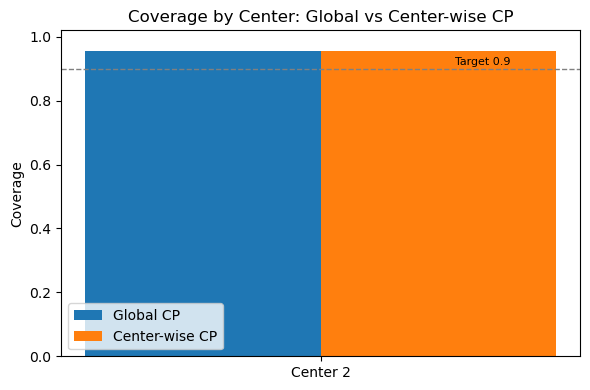

In [68]:
# assuming you have:
# center_cov      -> dict {center: coverage} from global CP
# cw_center_cov   -> dict {center: coverage} from center-wise CP

# get sorted list of centers that appear in either dict
centers_all = sorted(set(center_cov.keys()) | set(cw_center_cov.keys()))

global_vals = [center_cov.get(c, np.nan) for c in centers_all]
cw_vals     = [cw_center_cov.get(c, np.nan) for c in centers_all]

x = np.arange(len(centers_all))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, global_vals, width, label='Global CP')
plt.bar(x + width/2, cw_vals,     width, label='Center-wise CP')

plt.axhline(0.9, color='gray', linestyle='--', linewidth=1)
plt.text(len(centers_all)-0.8, 0.9+0.01, 'Target 0.9', fontsize=8)

plt.xticks(x, [f'Center {c}' for c in centers_all])
plt.ylim(0, 1.02)
plt.ylabel('Coverage')
plt.title('Coverage by Center: Global vs Center-wise CP')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# bar plot: overall coverage and average set size

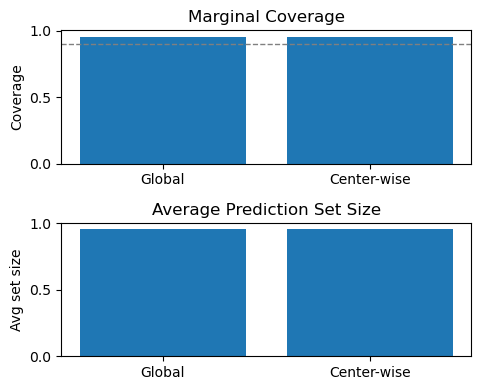

In [70]:
methods = ['Global', 'Center-wise']
covs    = [cov, cw_cov]
sizes   = [avg_size, cw_avg_size]

plt.figure(figsize=(5,4))
plt.subplot(2,1,1)
plt.bar(methods, covs)
plt.axhline(0.9, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Coverage')
plt.title('Marginal Coverage')

plt.subplot(2,1,2)
plt.bar(methods, sizes)
plt.ylabel('Avg set size')
plt.title('Average Prediction Set Size')
plt.tight_layout()
plt.show()


In [ ]:
# Histogram of nonconformity scores

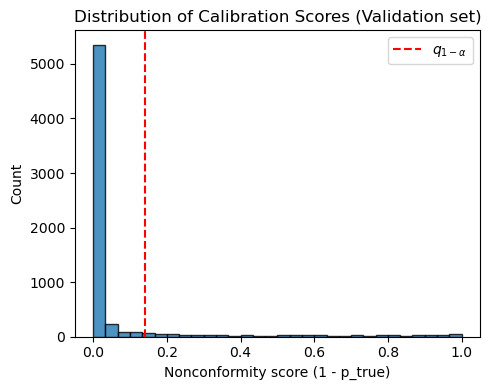

In [72]:
# if you DON'T have val_scores already, recompute quickly:
# p_true = val_probs[np.arange(len(val_labels)), val_labels]
# val_scores = 1.0 - p_true

plt.figure(figsize=(5,4))
plt.hist(val_scores, bins=30, alpha=0.8, edgecolor='black')
plt.axvline(global_q, color='red', linestyle='--', label=r'$q_{1-\alpha}$')

plt.xlabel('Nonconformity score (1 - p_true)')
plt.ylabel('Count')
plt.title('Distribution of Calibration Scores (Validation set)')
plt.legend()
plt.tight_layout()
plt.show()
